In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv(
    '../data/raw/02_nav_history.csv'
)

In [3]:
funds = [
    119551,
    119552,
    119598,
    119599,
    119120
]

nav = nav[
    nav['amfi_code'].isin(funds)
]

In [4]:
nav['date'] = pd.to_datetime(
    nav['date']
)

pivot = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

pivot = pivot.dropna()

In [5]:
returns = pivot.pct_change()

returns = returns.dropna()

returns.head()

amfi_code,119120,119551,119552,119598,119599
date,,,,,
2022-01-04,0.002651,-0.000702,-0.018306,-0.014735,-0.018716
2022-01-05,0.004416,0.006247,-0.005106,-0.005161,-0.001137
2022-01-06,0.003598,0.014045,-0.011091,0.004824,-0.007924
2022-01-07,-0.002465,-0.001547,0.015111,0.032830,-0.044252
2022-01-10,-0.000353,-0.001548,0.009465,0.051113,0.033761


In [6]:
mean_returns = (
    returns.mean()
    * 252
)

cov_matrix = (
    returns.cov()
    * 252
)

In [7]:
num_portfolios = 5000

results = np.zeros(
    (3, num_portfolios)
)

weights_record = []

In [8]:
for i in range(num_portfolios):

    weights = np.random.random(
        len(funds)
    )

    weights /= np.sum(
        weights
    )

    portfolio_return = np.sum(
        mean_returns * weights
    )

    portfolio_std = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix,
                weights
            )
        )
    )

    sharpe = (
        portfolio_return
        /
        portfolio_std
    )

    results[0, i] = portfolio_return
    results[1, i] = portfolio_std
    results[2, i] = sharpe

    weights_record.append(
        weights
    )

In [9]:
max_sharpe_idx = np.argmax(
    results[2]
)

best_return = results[
    0,
    max_sharpe_idx
]

best_risk = results[
    1,
    max_sharpe_idx
]

best_weights = weights_record[
    max_sharpe_idx
]

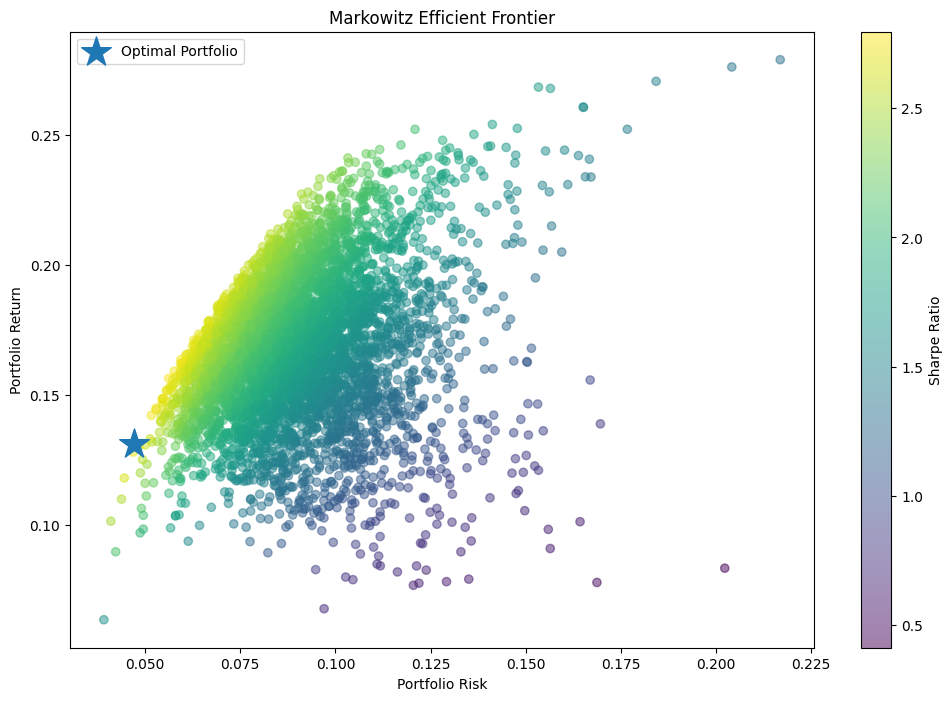

In [10]:
plt.figure(figsize=(12,8))

plt.scatter(
    results[1],
    results[0],
    c=results[2],
    alpha=0.5
)

plt.colorbar(
    label='Sharpe Ratio'
)

plt.scatter(
    best_risk,
    best_return,
    marker='*',
    s=500,
    label='Optimal Portfolio'
)

plt.title(
    'Markowitz Efficient Frontier'
)

plt.xlabel(
    'Portfolio Risk'
)

plt.ylabel(
    'Portfolio Return'
)

plt.legend()

plt.savefig(
    '../charts/efficient_frontier.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [11]:
allocation = pd.DataFrame({
    'amfi_code': funds,
    'weight_pct':
    best_weights * 100
})

allocation

,amfi_code,weight_pct
0,119551,55.290179
1,119552,15.356571
2,119598,20.999108
3,119599,7.581945
4,119120,0.772197


In [12]:
allocation.to_csv(
    '../reports/optimal_portfolio.csv',
    index=False
)

## Markowitz Portfolio Optimization

Markowitz Modern Portfolio Theory was used to identify the optimal allocation across five mutual funds.

Key Findings:

- 5000 random portfolios generated.
- Portfolio return and risk calculated using annualized returns and covariance matrix.
- Maximum Sharpe Ratio portfolio identified.
- Efficient Frontier visualized risk-return trade-offs.

The optimal portfolio achieved the highest risk-adjusted return among all simulated allocations.